# DL074 统计学习与泛化界

发行074映射原大纲T2。本Notebook从空内核实际重做完整实验。先预测结果，再逐单元执行；所有数据原创、CPU离线。图由固定outputs绘制，下面先核对重跑数组再展示。

In [1]:
from pathlib import Path  # 当前目录应为本单元。
import json, numpy as np  # 结果读取与数值核验。
from IPython.display import display, Image  # 内嵌PNG到Notebook。
print('working directory:', Path.cwd().name)  # 只显示目录名，避免机器路径。

working directory: 074


## 1 先做手算可核验的机制
数组形状与定义见data/README.md。不要把程序输出当作理解推导的替代。

In [2]:
from generate_data import population, sample  # 固定总体和独立抽样。
from experiment import radius, true_risks, empirical_risks  # 分开三类数字。
pop = population()  # 不用本次样本决定候选集合。
idx, y = sample(100, 7400)  # 100条独立样本。
truth = true_risks(pop['predictions'], pop['prob'])  # 已知总体精确求和。
emp = empirical_risks(pop['predictions'], idx, y)  # 经验风险。
print('radius:', radius(100, 23), 'max gap:', np.max(abs(emp-truth)))  # 真正计算。
print('candidate and distinct counts:', len(emp), len(np.unique(pop['predictions'], axis=0)))

radius: 0.1847210555140248 max gap: 0.10000000000000012
candidate and distinct counts: 23 22


In [3]:
best = int(np.argmin(emp))  # 并列选最小索引。
print('chosen, empirical, population:', best, emp[best], truth[best])  # 不混淆两个风险。
np.testing.assert_allclose(truth.min(), .15, atol=1e-14)  # 标签噪声的可核验基准。
print('n for radius <= .05:', int(np.ceil(np.log(2*23/.05)/(2*.05**2))))  # 足够样本量。

chosen, empirical, population: 11 0.11 0.15
n for radius <= .05: 1365


## 2 完整实验重跑
调用run确实重新计算全部预定配置；输出另存notebook_outputs。运行时间只反映当前CPU，不构成跨机器性能比较。

In [4]:
from experiment import run  # 与命令行相同完整入口。
result = run('notebook_outputs')  # 真实重新抽样或训练，不复用固定输出。
print('unit:', result['unit'], 'runtime:', result['runtime'])  # 保存真实版本与时间。

unit: 074 runtime: {'python': '3.12.14', 'numpy': '2.3.5', 'seconds': 0.17718717400020978, 'device': 'CPU', 'dtype': 'float64'}


In [5]:
for row in result['rows']:  # 每个样本量分别报告。
    print(row['n'], 'radius:', row['epsilon'], 'violations:', row['violation_count'])
    print('ERM train/population:', row['mean_train'], row['mean_true'])  # 选择偏差可见。

20 radius: 0.4130488370048718 violations: 1
ERM train/population: 0.13475 0.19758333333333333
100 radius: 0.1847210555140248 violations: 0
ERM train/population: 0.14934999999999998 0.15366666666666665
500 radius: 0.08260976740097437 violations: 0
ERM train/population: 0.149995 0.14999999999999997
2000 radius: 0.04130488370048718 violations: 0
ERM train/population: 0.1500825 0.14999999999999997


## 3 逐数组核对固定发行结果
同环境重跑应相同；跨BLAS或平台可能有舍入差，使用小容差。NaN仅在有明确定义的未定义量处按相同位置匹配。

In [6]:
reference = np.load('outputs/trials.npz', allow_pickle=False)  # 固定发行证据。
replayed = np.load('notebook_outputs/trials.npz', allow_pickle=False)  # 刚重跑结果。
if set(reference.files) != set(replayed.files):  # 不依赖可被-O删掉的assert。
    raise ValueError('array keys differ')
for name in reference.files:  # 每个数组都检查，不只检查摘要。
    np.testing.assert_allclose(replayed[name], reference[name], rtol=1e-10, atol=1e-11, equal_nan=True)
print('checked arrays:', len(reference.files))  # 实际核验数量。

checked arrays: 9


## 4 读图并写出限制
图是make_figures.py由固定outputs产生；上一单元已核对刚重跑的全部数组。改变实验后应重新画图，不能继续把旧图当新结果。

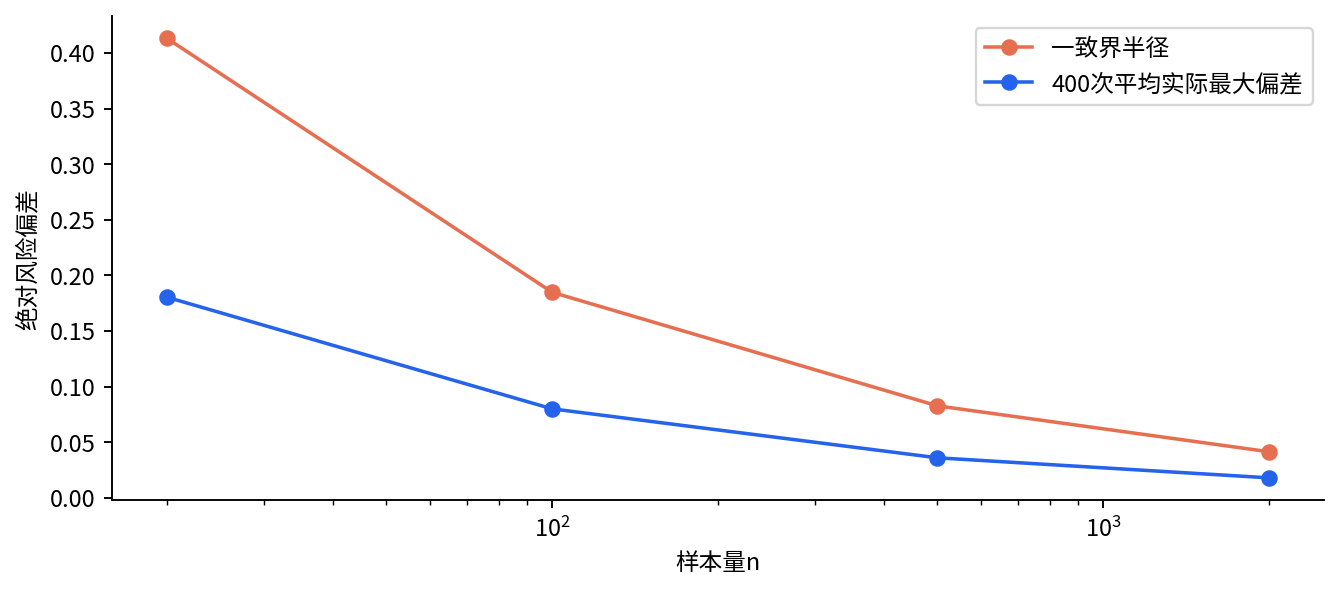

In [7]:
display(Image(filename='figures/03_bound.png'))  # 内嵌真实结果图。

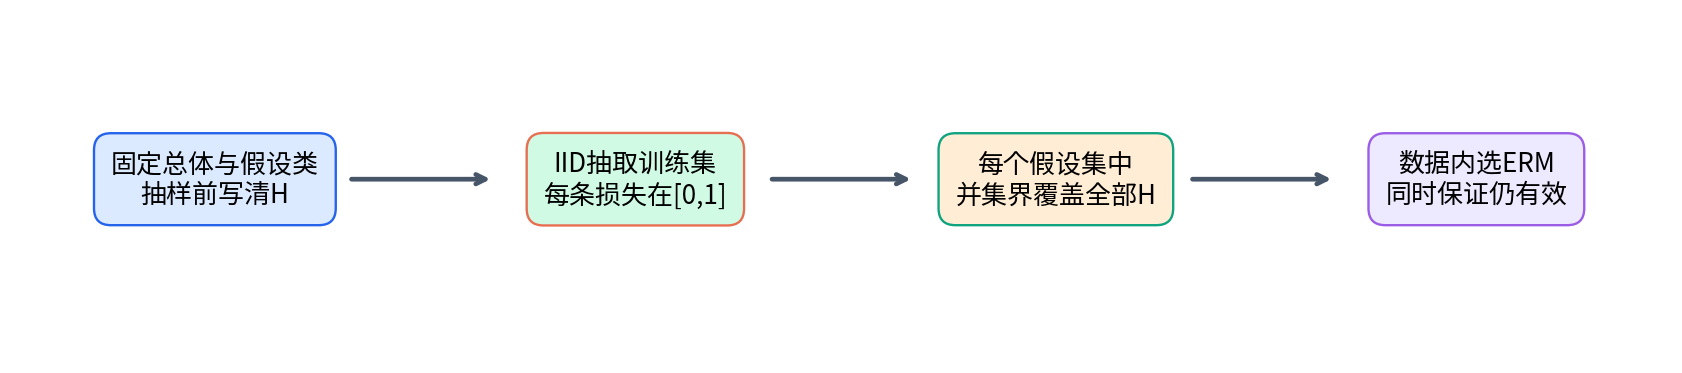

In [8]:
display(Image(filename='figures/01_uniform.png'))  # 机制图不是额外实验结果。

## 5 自检
回到lab完成故障注入与扩展设计。明确已执行和仅提出的实验，解释至少一条不能外推的条件。答案在answers.md，不使用测试结果挑选最好配置。